Hypothesis testing & PRC of simple de novo simulation.

(outdated : need to modify to deal w/ precomputing orthos)

In [1]:
#imports
import scMPRAforge as scm
import pandas as pd
import numpy as np
from dask.distributed import Client, LocalCluster

2025-09-22 16:37:56.247198: I tensorflow/core/util/util.cc:169] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2025-09-22 16:37:56.251971: W tensorflow/stream_executor/platform/default/dso_loader.cc:64] Could not load dynamic library 'libcudart.so.11.0'; dlerror: libcudart.so.11.0: cannot open shared object file: No such file or directory; LD_LIBRARY_PATH: /vast/palmer/apps/avx2/software/Code-Server/4.17.0/lib:/vast/palmer/apps/avx2/software/gettext/0.22.5-GCCcore-13.3.0/lib:/vast/palmer/apps/avx2/software/libiconv/1.17-GCCcore-13.3.0/lib:/vast/palmer/apps/avx2/software/ncurses/6.5-GCCcore-13.3.0/lib:/vast/palmer/apps/avx2/software/libxml2/2.12.7-GCCcore-13.3.0/lib:/vast/palmer/apps/avx2/software/XZ/5.4.5-GCCcore-13.3.0/lib:/vast/palmer/apps/avx2/software/expat/2.6.2-GCCcore-13.3.0/lib:/vast/palmer/apps/av

In [2]:
#autoreload
%load_ext autoreload
%autoreload 2

In [3]:
#set up cluster
local=False

if local:
    cluster=LocalCluster(memory_limit='4GB',n_workers=3,threads_per_worker=4,)
    client=Client(cluster)
else:
    from dask_jobqueue import SLURMCluster
    from dask.distributed import Client

    cluster=SLURMCluster(
        cores=2,#cores per slurm job
        memory="16G",#memory per slurm job
        processes=1,#dask workers
        job_extra_directives=["-p ycga", 
            f"--job-name=simclust_worker",
            f"--time=3:00:00",
            f"--output=slave_%j.out"]
    )

    cluster.scale(jobs=6)

    client = Client(cluster,
            timeout=f"{5*60}s",   # Client <-> scheduler timeout 
            heartbeat_interval="20s"  # Worker heartbeat interval
        )


In [4]:
#load sim & hypo test
data_root="/gpfs/gibbs/pi/reilly/tabula_data"

#hypothesis_set=scm.HypothesisSet.from_tsv(f"{data_root}/simulated/activity_de_novo_hypotheses.tsv")
hypothesis_set=scm.HypothesisSet.from_tsv(f"{data_root}/simulated/activity_de_novo_hypotheses.tsv")

In [22]:
de_novo_sim=None
first_time=True
if first_time:
    de_novo_sim=scm.de_novo_simulation.load(client,data_root,"simulated/activity_de_novo_and_results")
    #de_novo_sim._test_replicate(client,hypothesis_set,test="wald",index=0)
    de_novo_sim._test_replicate(client,hypothesis_set,test="wald",index=1)
    de_novo_sim._test_replicate(client,hypothesis_set,test="wald",index=2)
    
    #de_novo_sim._test_replicate(client,hypothesis_set,test="mwu",index=0)
    #de_novo_sim._test_replicate(client,hypothesis_set,test="mwu",index=1)
    #de_novo_sim._test_replicate(client,hypothesis_set,test="mwu",index=2)
    de_novo_sim.save(data_root,"simulated/activity_de_novo_and_results")
else:
    de_novo_sim=scm.de_novo_simulation.load(client,data_root,"simulated/activity_de_novo_and_results")

scMPRAforge: WARNING: Directory /gpfs/gibbs/pi/reilly/tabula_data/simulated/activity_de_novo_and_results already exists, continuing.
scMPRAforge: WARNING: Directory /gpfs/gibbs/pi/reilly/tabula_data/simulated/activity_de_novo_and_results/descriptions already exists, continuing.


In [14]:
de_novo_sim.crosstab(test="wald",index=0)

reject_null,False,True
gt_null,,
False,81,1585
True,3925,52


In [20]:
de_novo_sim.crosstab(test="mwu",index=0)

reject_null,False,True
gt_null,,
False,91,1575
True,3918,29


In [18]:
de_novo_sim.crosstab(test="mwu",index=1)

reject_null,False,True
gt_null,,
False,84,1582
True,4278,56


In [7]:
de_novo_sim.crosstab(test="mwu",index=2)

reject_null,False,True
gt_null,,
False,87,1579
True,4287,47


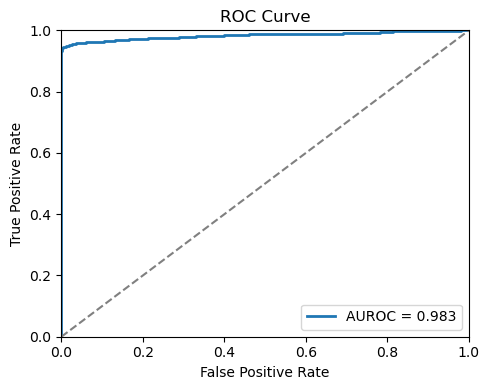

In [19]:
de_novo_sim.roc(test="mwu",index=0)

In [ ]:
roc(de_novo_sim,test="wald",index=0)

In [ ]:
_merge_in_ground_truth

Troubleshooting missing results

In [ ]:
merged=de_novo_sim._merge_in_ground_truth(test="mwu",index=0)
df=merged.drop(columns=["meta"])
mwu_na=df[df.isna().any(axis=1)]


In [ ]:
merged=de_novo_sim._merge_in_ground_truth(test="wald",index=0)
df=merged.drop(columns=["meta"])
wald_na=df[df.isna().any(axis=1)]

In [ ]:
mwu_na

In [ ]:
wald_na

In [ ]:
merged

In [ ]:
cols = ["comparison_CRE", "reference_CRE",
        "comparison_cell_type", "reference_cell_type"]

# Convert each row into a tuple so we can compare sets
set1 = set(map(tuple, wald_na[cols].values))
set2 = set(map(tuple, mwu_na[cols].values))

# Venn diagram info
only_df1 = set1 - set2
only_df2 = set2 - set1
both     = set1 & set2

print("Unique to df1:", len(only_df1))
print("Unique to df2:", len(only_df2))
print("Shared:", len(both))

In [ ]:
hypothesis_set.df

In [8]:
cluster.close()
client.close()